In [133]:
import pandas as pd
import numpy as np

In [134]:
pd.__version__

'3.0.5'

In [135]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [136]:
# Preparing dataset

df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [137]:
import seaborn as sns

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

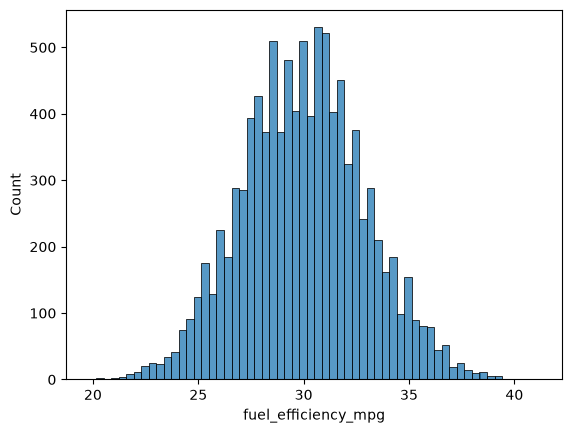

In [138]:
#EDA

sns.histplot(df.fuel_efficiency_mpg)

The `fuel_efficiency_mpg` feature does not seems to have a long tail

In [139]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Question 1 answer: We can se that `horsepower` is the only column with missing values

In [140]:
df.horsepower.median()

np.float64(254.0)

### Question 2 answer: The median of `horsepower` is 254

In [141]:
# Preparing and spliting the dataset

n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[: n_train]]
df_val = df.iloc[idx[n_train : n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val :]]

y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

print('Data prepared')

Data prepared


In [142]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

def prepare_X(df, fillna_value = 0):
    return df[base].fillna(fillna_value).values

def root_mean_square_error(y, y_pred):
    square_error = (y - y_pred) ** 2
    mean_se = square_error.mean()
    return np.sqrt(mean_se)

In [143]:
# Question 3: using 0 to fill horsepower

fillna_value = 0

X_train = prepare_X(df_train, fillna_value)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, fillna_value)
y_pred = w0 + X_val.dot(w)

result = root_mean_square_error(y_val, y_pred)

round(result, 3)

np.float64(0.071)

<Axes: ylabel='Count'>

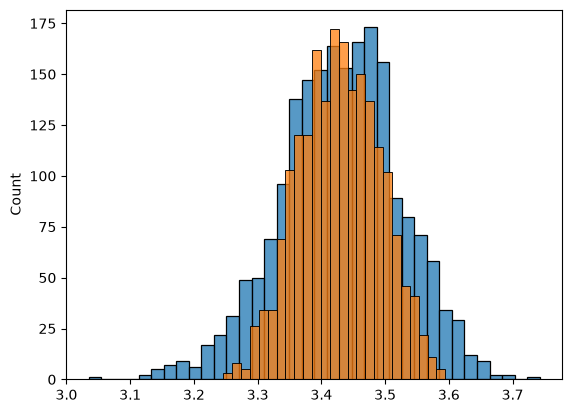

In [144]:
sns.histplot(y_val)
sns.histplot(y_pred)

In [145]:
# Question 3: using the horsepower's mean to fill horsepower

fillna_value = df_train[base].horsepower.mean()
X_train = prepare_X(df_train, fillna_value) # WARNING: This works at the moment only because horsepower is the only feature with null values
w0, w = train_linear_regression(X_train, y_train)

fillna_value = df_val[base].horsepower.mean()
X_val = prepare_X(df_val, fillna_value)
y_pred = w0 + X_val.dot(w)

result = root_mean_square_error(y_val, y_pred)

round(result, 3)

np.float64(0.071)

<Axes: ylabel='Count'>

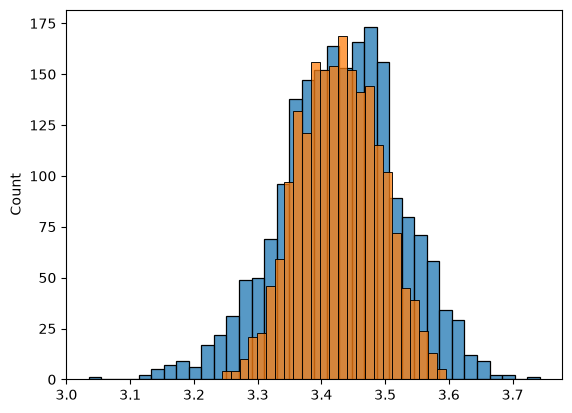

In [146]:
sns.histplot(y_val)
sns.histplot(y_pred)

### Question 3 answer: both are equally good

In [147]:
def prepare_X(df):
    return df[base].fillna(0).values

def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X) 
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [148]:
X_train = prepare_X(df_train)

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r_values:
    w0, w = train_linear_regression_reg(X_train, y_train, r)

    y_pred = w0 + X_train.dot(w)

    rmse = root_mean_square_error(y_train, y_pred)

    print(f'r == {r}: {round(rmse, 4)}')


r == 0: 0.0713
r == 0.01: 0.0713
r == 0.1: 0.0714
r == 1: 0.0725
r == 5: 0.0731
r == 10: 0.0732
r == 100: 0.0733


### Question 4 answer: r == 0 is the correct option

In [149]:
seed_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

rmse_values = []

for seed in seed_values:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[: n_train]]
    df_val = df.iloc[idx[n_train : n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val :]]

    y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
    y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
    y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

    X_train = prepare_X(df_train)

    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val)

    y_pred = w0 + X_val.dot(w)

    rmse = root_mean_square_error(y_val, y_pred)

    rmse_values.append(rmse)

np.std(rmse_values).round(3)

np.float64(0.001)